In [2]:
import numpy as np
import matplotlib.pyplot as plt

x=np.linspace(-1.0,1.0,100)
x
x[:10]


array([-1.        , -0.97979798, -0.95959596, -0.93939394, -0.91919192,
       -0.8989899 , -0.87878788, -0.85858586, -0.83838384, -0.81818182])

In [3]:
!pip install torch

In [4]:
#Defining the quantization
min_x = -1.0
max_x = 1.0
qmin=-128
qmax=127

scale=(max_x-min_x)/(qmax-qmin)
scale


0.00784313725490196

In [5]:
zero_point = 0

q = np.round((x-zero_point)/scale).astype(int)

q[::]

array([-128, -125, -122, -120, -117, -115, -112, -109, -107, -104, -102,
        -99,  -97,  -94,  -91,  -89,  -86,  -84,  -81,  -79,  -76,  -73,
        -71,  -68,  -66,  -63,  -61,  -58,  -55,  -53,  -50,  -48,  -45,
        -42,  -40,  -37,  -35,  -32,  -30,  -27,  -24,  -22,  -19,  -17,
        -14,  -12,   -9,   -6,   -4,   -1,    1,    4,    6,    9,   12,
         14,   17,   19,   22,   24,   27,   30,   32,   35,   37,   40,
         43,   45,   48,   50,   53,   55,   58,   61,   63,   66,   68,
         71,   73,   76,   79,   81,   84,   86,   89,   91,   94,   97,
         99,  102,  104,  107,  109,  112,  115,  117,  120,  122,  125,
        128])

In [6]:
#Dequentization: int8 -> flot

x_hat = scale*(q-zero_point)
x_hat



array([-1.00392157, -0.98039216, -0.95686275, -0.94117647, -0.91764706,
       -0.90196078, -0.87843137, -0.85490196, -0.83921569, -0.81568627,
       -0.8       , -0.77647059, -0.76078431, -0.7372549 , -0.71372549,
       -0.69803922, -0.6745098 , -0.65882353, -0.63529412, -0.61960784,
       -0.59607843, -0.57254902, -0.55686275, -0.53333333, -0.51764706,
       -0.49411765, -0.47843137, -0.45490196, -0.43137255, -0.41568627,
       -0.39215686, -0.37647059, -0.35294118, -0.32941176, -0.31372549,
       -0.29019608, -0.2745098 , -0.25098039, -0.23529412, -0.21176471,
       -0.18823529, -0.17254902, -0.14901961, -0.13333333, -0.10980392,
       -0.09411765, -0.07058824, -0.04705882, -0.03137255, -0.00784314,
        0.00784314,  0.03137255,  0.04705882,  0.07058824,  0.09411765,
        0.10980392,  0.13333333,  0.14901961,  0.17254902,  0.18823529,
        0.21176471,  0.23529412,  0.25098039,  0.2745098 ,  0.29019608,
        0.31372549,  0.3372549 ,  0.35294118,  0.37647059,  0.39

/tmp/ipython-input-4074903065.py:19: UserWarning: Glyph 12584 (\N{BOPOMOFO LETTER U}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12584 (\N{BOPOMOFO LETTER U}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


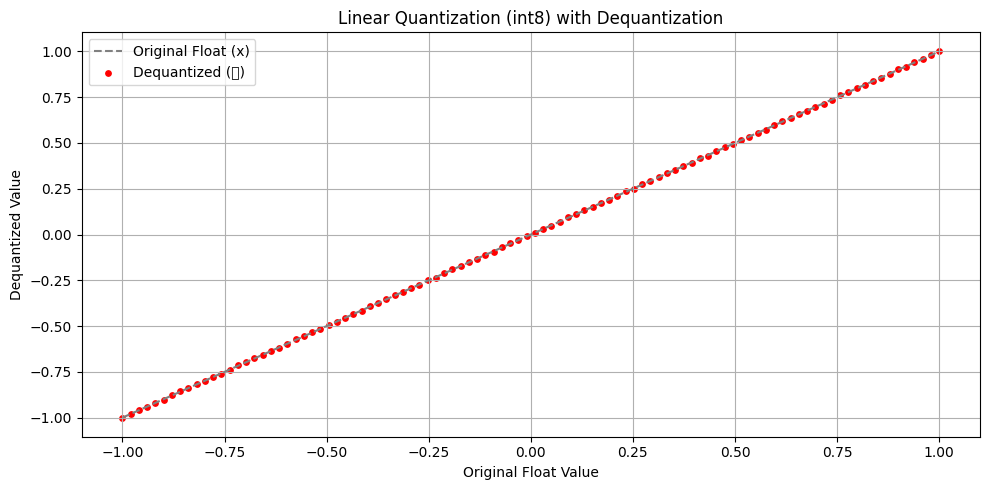

In [7]:
# Plot original vs. dequantized

plt.figure(figsize=(10, 5))

plt.plot(x, x, label='Original Float (x)', linestyle='--', color="gray")

plt.scatter(x, x_hat, label='Dequantized (ㄨ)', color='red', s=15)

plt.title('Linear Quantization (int8) with Dequantization')

plt.xlabel('Original Float Value')

plt.ylabel('Dequantized Value')

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.show()

In [8]:
!pip install unsloth

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.5/61.5 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.8/348.8 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.4/59.4 MB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 38.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 564.7/564.7 kB 41.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 276.7/276.7 kB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.2/117.2 MB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.6/132.6 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.7/47.7 MB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 57.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 213.6/213.6 kB 10.4 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      

In [9]:
#Load pretrained LLMs
from unsloth import FastLanguageModel
#to handle all model tensors and computations.
import torch

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


In [10]:
!nvidia-smi


Tue Nov  4 07:17:04 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   56C    P0             26W /   70W |     102MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [11]:
#maximum number of tokens (words, subwords, punctuation, etc.) the model can process
max_seq_length = 2048
#Unsloth automatically chooses the best type based on your GPU and load_in_4bit
#torch.float16
#torch.float32 in bits
dtype=None
load_in_4bit = True

In [12]:
#Loading the pretrained unsloth model
model, tokenizer = FastLanguageModel.from_pretrained(
    #name of the loded model
    model_name = "unsloth/Llama-3.2-3B-Instruct",

    #this are defined in earlier
    max_seq_length = max_seq_length,
    #it will alto select the precision type
    dtype = dtype,

    load_in_4bit = load_in_4bit,#4bit quantiization
)

==((====))==  Unsloth 2025.11.1: Fast Llama patching. Transformers: 4.57.1.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.741 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.8.0+cu126. CUDA: 7.5. CUDA Toolkit: 12.6. Triton: 3.4.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.32.post2. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/2.35G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/234 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/454 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

| **LoRA Formula**                | **Meaning**                                                                |
| ------------------------------- | -------------------------------------------------------------------------- |
| ( W' = W + \frac{α}{r}(A × B) ) | Base weight (W) is frozen; only low-rank matrices (A) and (B) are trained. |
| **Goal**                        | Reduce number of trainable parameters while preserving performance.        |
| **Effect**                      | Makes fine-tuning large LLMs possible on a single GPU with minimal memory. |


In [13]:
model = FastLanguageModel.get_peft_model(
    model,
    # rank (8, 32, 64, 128)
    r = 16,  # LoRA rank

    target_modules = [
        "q_proj", "v_proj", "k_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj"
    ],  # Wq + ΔW, Wk + ΔW

    # Formula: W' = W + (α / r) × (A × B)
    lora_alpha = 16,               # scaling factor
    lora_dropout = 0,              # dropout rate for LoRA adapters
    bias = "none",                 # no bias added
    use_gradient_checkpointing = "unsloth",  # save VRAM during training
    random_state = 3407,           # reproducibility
    use_rslora = False,            # disable Rank Stabilized LoRA
    loftq_config = None            # not using LoftQ quantization
)


Unsloth 2025.11.1 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.


| **Parameter / Instance**     | **Example Value**                                                               | **Description / Functionality**                                                                                                                                          |
| ---------------------------- | ------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------ |
| `model`                      | `model`                                                                         | The base pretrained model that will be fine-tuned using LoRA adapters.                                                                                                   |
| `r`                          | `16`                                                                            | **LoRA rank** — determines the dimensionality of the low-rank matrices (A) and (B). <br>Higher `r` → more trainable parameters, better accuracy but higher memory usage. |
| `target_modules`             | `["q_proj", "v_proj", "k_proj", "o_proj", "gate_proj", "up_proj", "down_proj"]` | Specifies which model layers to inject LoRA adapters into (typically the projection layers of the Transformer).                                                          |
| `lora_alpha`                 | `16`                                                                            | **Scaling factor (α)** in LoRA formula (W' = W + \frac{α}{r}(A×B)). <br>Controls the impact of LoRA updates relative to the base weights.                                |
| `lora_dropout`               | `0`                                                                             | Dropout rate applied to LoRA layers during training — adds regularization to prevent overfitting.                                                                        |
| `bias`                       | `"none"`                                                                        | Whether to add bias terms in LoRA layers. `"none"` means no bias added.                                                                                                  |
| `use_gradient_checkpointing` | `"unsloth"`                                                                     | Enables **gradient checkpointing** to save VRAM by re-computing some activations during backward pass (slower but memory-efficient).                                     |
| `random_state`               | `3407`                                                                          | Random seed for reproducibility of training results.                                                                                                                     |
| `use_rslora`                 | `False`                                                                         | Enables or disables **Rank-Stabilized LoRA (RS-LoRA)**, which dynamically adjusts LoRA ranks to stabilize training — disabled here.                                      |
| `loftq_config`               | `None`                                                                          | Config for **LoftQ (Low-Rank Factorization + Quantization)** — allows quantized LoRA fine-tuning. Here it’s not used.                                                    |


In [14]:
from datasets import load_dataset
ds = load_dataset("ServiceNow-AI/R1-Distill-SFT", "v0")

README.md: 0.00B [00:00, ?B/s]

v0/train-00000-of-00003.parquet:   0%|          | 0.00/180M [00:00<?, ?B/s]

v0/train-00001-of-00003.parquet:   0%|          | 0.00/187M [00:00<?, ?B/s]

v0/train-00002-of-00003.parquet:   0%|          | 0.00/188M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/171647 [00:00<?, ? examples/s]

In [15]:
ds

DatasetDict({
    train: Dataset({
        features: ['id', 'reannotated_assistant_content', 'problem', 'source', 'solution', 'verified', 'quality_metrics'],
        num_rows: 171647
    })
})

In [28]:
display(ds['train'][:2])

{'id': ['id_0', 'id_1'],
 'reannotated_assistant_content': ['<think>\nFirst, I need to determine the total number of children on the playground by adding the number of boys and girls.\n\nThere are 27 boys and 35 girls.\n\nAdding these together: 27 boys + 35 girls = 62 children.\n\nTherefore, the total number of children on the playground is 62.\n</think>\n\nTo find the total number of children on the playground, we simply add the number of boys and girls together.\n\n\\[\n\\text{Total children} = \\text{Number of boys} + \\text{Number of girls}\n\\]\n\nPlugging in the given values:\n\n\\[\n\\text{Total children} = 27 \\text{ boys} + 35 \\text{ girls} = 62 \\text{ children}\n\\]\n\n**Final Answer:**\n\n\\[\n\\boxed{62}\n\\]',
  '<think>\nFirst, I need to determine the cost per dozen oranges. John bought three dozen oranges for \\$28.80, so I can find the cost per dozen by dividing the total cost by the number of dozens.\n\nNext, with the cost per dozen known, I can calculate the cost fo

In [17]:
ds.shape

{'train': (171647, 7)}

In [18]:
# Define the reinforcement-learning style prompt template
rl_prompt = """You are a reflective assistant engaging in thorough, iterative reasoning, mimicking human stream-of-consciousness.
<problem>
{}
</problem>

{}
{}
"""

# End of sequence token (marks the end of each training example)
EOS_TOKEN = tokenizer.eos_token

# Function to format each example in the dataset
def formatting_prompts_func(examples):
    problems = examples["problem"]                       # Input problem/question
    thoughts = examples["reannotated_assistant_content"] # Model reasoning or chain of thought
    solutions = examples["solution"]                     # Final answer
    texts = []

    # Combine each problem, reasoning, and solution into one formatted prompt
    for problem, thought, solution in zip(problems, thoughts, solutions):
        text = rl_prompt.format(problem, thought, solution) + EOS_TOKEN
        texts.append(text)

    # Return as a dictionary (dataset.map expects this format)
    return {"text": texts}

# Apply formatting function to entire dataset
ds = ds.map(formatting_prompts_func, batched=True)


Map:   0%|          | 0/171647 [00:00<?, ? examples/s]

In [19]:
ds

DatasetDict({
    train: Dataset({
        features: ['id', 'reannotated_assistant_content', 'problem', 'source', 'solution', 'verified', 'quality_metrics', 'text'],
        num_rows: 171647
    })
})

In [20]:
ds['train'][1]

{'id': 'id_1',
 'reannotated_assistant_content': '<think>\nFirst, I need to determine the cost per dozen oranges. John bought three dozen oranges for \\$28.80, so I can find the cost per dozen by dividing the total cost by the number of dozens.\n\nNext, with the cost per dozen known, I can calculate the cost for five dozen oranges by multiplying the cost per dozen by five.\n\nFinally, I will present the final answer clearly.\n</think>\n\n**Solution:**\n\nTo determine the cost of five dozen oranges at the same rate, follow these steps:\n\n1. **Find the cost per dozen:**\n\n   John purchased three dozen oranges for \\$28.80. To find the cost per dozen, divide the total cost by the number of dozens.\n\n   \\[\n   \\text{Cost per dozen} = \\frac{\\$28.80}{3} = \\$9.60 \\text{ per dozen}\n   \\]\n\n2. **Calculate the cost for five dozen:**\n\n   Now, multiply the cost per dozen by the number of dozens needed.\n\n   \\[\n   \\text{Cost for five dozen} = 5 \\times \\$9.60 = \\$48.00\n   \\]\n

| **Parameter**        | **Example Value**        | **Description / Functionality**                                            |
| -------------------- | ------------------------ | -------------------------------------------------------------------------- |
| `model`              | `model`                  | The pretrained base model that will be fine-tuned.                         |
| `tokenizer`          | `tokenizer`              | Tokenizer used to convert text into model-readable tokens.                 |
| `train_dataset`      | `ds["train"]`            | Training dataset split used for supervised fine-tuning.                    |
| `dataset_text_field` | `"text"`                 | Column name in the dataset containing training text data.                  |
| `max_seq_length`     | `max_seq_length`         | Maximum token length for each training example.                            |
| `dataset_num_proc`   | `2`                      | Number of CPU processes for dataset preprocessing (parallelism).           |
| `packing`            | `False`                  | Whether to pack multiple short examples into one sequence (disabled here). |
| `args`               | `TrainingArguments(...)` | Holds all hyperparameters and runtime configurations for training.         |


In [21]:
from unsloth import is_bfloat16_supported
from transformers import TrainingArguments, DataCollatorForSeq2Seq
from trl import SFTTrainer


trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = ds["train"],             # processed dataset
    dataset_text_field = "text",    # column name in dataset
    max_seq_length = max_seq_length,
    dataset_num_proc = 2,           # CPU threads for preprocessing
    packing = False,                # keep sequences separate

    args = TrainingArguments(
        per_device_train_batch_size = 2,       # batch size per GPU core
        gradient_accumulation_steps = 4,       # accumulate gradients
        warmup_steps = 5,                      # warmup steps
        max_steps = 60,                        # total training steps
        learning_rate = 2e-4,                  # fine-tuning LR
        fp16 = not is_bfloat16_supported(),    # use float16 if bf16 unsupported
        bf16 = is_bfloat16_supported(),        # T4 supports bf16
        logging_steps = 1,                     # log after each step
        optim = "adamw_8bit",                  # memory-efficient optimizer
        weight_decay = 0.01,
        lr_scheduler_type = "linear",
        seed = 3407,
        output_dir = "outputs",                # save checkpoints
        report_to = "none",                    # disable WandB/HF logging
    ),
)


Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/171647 [00:00<?, ? examples/s]

| **Parameter**                 | **Example Value**             | **Description / Functionality**                                                                       |
| ----------------------------- | ----------------------------- | ----------------------------------------------------------------------------------------------------- |
| `per_device_train_batch_size` | `2`                           | Number of samples per GPU per training step.                                                          |
| `gradient_accumulation_steps` | `4`                           | Number of steps to accumulate gradients before updating model weights (effective batch size = 2×4=8). |
| `warmup_steps`                | `5`                           | Gradually increases learning rate during the first 5 steps to stabilize training.                     |
| `max_steps`                   | `60`                          | Total number of training steps (iterations) to run.                                                   |
| `learning_rate`               | `2e-4`                        | The fine-tuning learning rate.                                                                        |
| `fp16`                        | `not is_bfloat16_supported()` | Enables 16-bit float precision if bf16 isn’t supported (saves memory).                                |
| `bf16`                        | `is_bfloat16_supported()`     | Enables bfloat16 precision if GPU supports it (more stable training).                                 |
| `logging_steps`               | `1`                           | Logs training metrics every step.                                                                     |
| `optim`                       | `"adamw_8bit"`                | Uses 8-bit AdamW optimizer for memory-efficient fine-tuning.                                          |
| `weight_decay`                | `0.01`                        | Regularization term to prevent overfitting.                                                           |
| `lr_scheduler_type`           | `"linear"`                    | Type of learning rate schedule (linearly decays over time).                                           |
| `seed`                        | `3407`                        | Random seed for reproducibility.                                                                      |
| `output_dir`                  | `"outputs"`                   | Directory where checkpoints and logs are saved.                                                       |
| `report_to`                   | `"none"`                      | Disables logging to external services (like WandB or Hugging Face Hub).                               |


In [24]:
trainer_status=trainer.train()

The model is already on multiple devices. Skipping the move to device specified in `args`.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 171,647 | Num Epochs = 1 | Total steps = 60
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 24,313,856 of 3,237,063,680 (0.75% trained)


Step,Training Loss
1,0.545200
2,0.476700
3,0.551400
4,0.487500
5,0.418200
6,0.434400
7,0.381400
8,0.421600
9,0.458700
10,0.457700


In [25]:
from unsloth.chat_templates import get_chat_template

sys_prompt = """
You are a reflective assistant engaging in thorough, iterative reasoning,
mimicking human stream-of-consciousness thought.
<problem>
{}
</problem>
"""

message = sys_prompt.format("How many 'r's are present in 'strawberry'?")

tokenizer = get_chat_template(
    tokenizer,
    chat_template="llama-3.1",
)

FastLanguageModel.for_inference(model)  # Enable native 2x faster inference

messages = [
    {"role": "user", "content": message},
]

inputs = tokenizer.apply_chat_template(
    messages,
    tokenize=True,
    add_generation_prompt=True,   # Must be True for text generation
    return_tensors="pt",          # Return PyTorch tensors
).to("cuda")

outputs = model.generate(
    input_ids=inputs,
    max_new_tokens=1024,
    use_cache=True,
    temperature=1.5,
    min_p=0.1,
)

response = tokenizer.batch_decode(outputs)


The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


In [27]:
print(response[0])


<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 26 July 2024

<|eot_id|><|start_header_id|>user<|end_header_id|>


You are a reflective assistant engaging in thorough, iterative reasoning, 
mimicking human stream-of-consciousness thought.
<problem>
How many 'r's are present in'strawberry'?
</problem>
<|eot_id|><|start_header_id|>assistant<|end_header_id|>

Alright, let me try to figure out how many 'r's are in'strawberry'. Okay, so I remember that in English, sometimes there are repeated letters in words, like'strawberry' where there are three 'r's. But how do I count them?

First, I think I need to look at each letter individually and count the 'r's separately. Maybe it's easier to break it down letter by letter. Let me start by writing out the word'strawberry' again:

S-T-R-A-W-B-E-R-R-Y

Now, I need to find all the places where 'r' appears in this word. Let's do that letter by letter.

Starting from the beginning:

1. S 